In [1]:
import os
print(os.getcwd())

os.chdir("/home/tanasa/CHEMISTRY_GNN/data")
print(os.getcwd())

/home/tanasa/CHEMISTRY_GNN
/home/tanasa/CHEMISTRY_GNN/data


In [2]:
print("""

RDKit + SMILES + SELFIES + Molecular Similarity Tutorial
========================================================

This file combines the RDKit code examples we discussed into one organized
Python script. It includes both executable code and explanations as comments.

Topics covered:
- Reading molecules from SMILES, MOL, and SDF files
- Drawing molecules
- MOL/SDF writing
- Atoms, bonds, neighbors, rings
- Kekulization and aromaticity
- 2D/3D coordinates and conformers
- Substructure search and replacement
- Molecular fingerprints
- Tanimoto and Dice similarity
- SELFIES encoding/decoding
- Aspirin as a worked example

Notes:
- Some file paths such as data/input.mol or data/5ht3ligs.sdf are examples
  from the RDKit tutorial. Replace them with your own files if needed.
- In Jupyter, `display(img)` will show molecule images directly.
- In a terminal script, images can be saved with `img.save(...)`.
"""

)



RDKit + SMILES + SELFIES + Molecular Similarity Tutorial

This file combines the RDKit code examples we discussed into one organized
Python script. It includes both executable code and explanations as comments.

Topics covered:
- Reading molecules from SMILES, MOL, and SDF files
- Drawing molecules
- MOL/SDF writing
- Atoms, bonds, neighbors, rings
- Kekulization and aromaticity
- 2D/3D coordinates and conformers
- Substructure search and replacement
- Molecular fingerprints
- Tanimoto and Dice similarity
- SELFIES encoding/decoding
- Aspirin as a worked example

Notes:
- Some file paths such as data/input.mol or data/5ht3ligs.sdf are examples
  from the RDKit tutorial. Replace them with your own files if needed.
- In Jupyter, `display(img)` will show molecule images directly.
- In a terminal script, images can be saved with `img.save(...)`.



In [3]:
from pathlib import Path

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit import DataStructs

try:
    import selfies as sf
except ImportError:
    sf = None

try:
    from IPython.display import display, SVG
except ImportError:
    display = None
    SVG = None

In [4]:
# ============================================================
# 0. OUTPUT FOLDER + VISUALIZATION HELPERS
# ============================================================

OUTDIR = Path("rdkit_visual_outputs")
OUTDIR.mkdir(exist_ok=True)


def show_mol(mol, title="molecule", filename=None, size=(350, 300)):
    """
    Draw one molecule, display it in Jupyter, and save it as PNG.
    """
    if mol is None:
        print(f"{title}: molecule is None, cannot visualize.")
        return None

    img = Draw.MolToImage(mol, size=size, legend=title)

    if display is not None:
        display(img)

    if filename is None:
        filename = title.lower().replace(" ", "_").replace("/", "_") + ".png"

    path = OUTDIR / filename
    img.save(path)
    print(f"Saved: {path}")
    return img




In [5]:
OUTDIR = Path("rdkit_visual_outputs")
OUTDIR.mkdir(exist_ok=True)

def show_grid(
    mols,
    legends=None,
    title="molecule_grid",
    mols_per_row=4,
    sub_img_size=(250, 220),
):
    mols = [m for m in mols if m is not None]

    if legends is None:
        legends = [f"Mol {i}" for i in range(len(mols))]

    img = Draw.MolsToGridImage(
        mols,
        molsPerRow=mols_per_row,
        subImgSize=sub_img_size,
        legends=legends,
    )

    display(img)

    return img

def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)



def print_section(title):
    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)



1. SMILES -> RDKit molecule -> image
SMILES: Cc1ccccc1
RDKit molecule object: <rdkit.Chem.rdchem.Mol object at 0x78d3364e1e70>
Canonical SMILES: Cc1ccccc1


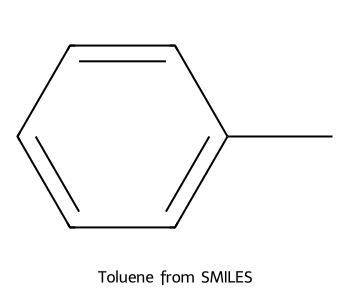

Saved: rdkit_visual_outputs/01_toluene.png


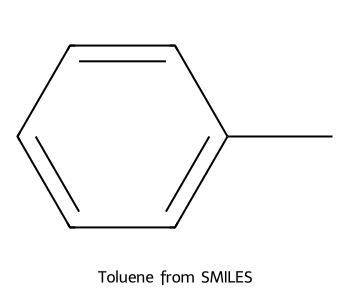

In [6]:
# ============================================================
# 1. BASIC SMILES -> MOLECULE -> IMAGE
# ============================================================

print_section("1. SMILES -> RDKit molecule -> image")

smiles_toluene = "Cc1ccccc1"  # toluene / methylbenzene
mol_toluene = Chem.MolFromSmiles(smiles_toluene)

print("SMILES:", smiles_toluene)
print("RDKit molecule object:", mol_toluene)
print("Canonical SMILES:", Chem.MolToSmiles(mol_toluene))

show_mol(mol_toluene, title="Toluene from SMILES", filename="01_toluene.png")


In [7]:
# ============================================================
# 2. INVALID SMILES EXAMPLES
# ============================================================

print_section("2. Invalid SMILES examples")

invalid_smiles_list = [
    "CO(C)C",  # oxygen valence problem
    "c1cc1",   # aromaticity/kekulization problem
]

for smi in invalid_smiles_list:
    bad_mol = Chem.MolFromSmiles(smi)
    print(f"SMILES: {smi} ->", bad_mol)
    if bad_mol is not None:
        show_mol(bad_mol, title=f"Parsed {smi}")
    else:
        print("Result: invalid / RDKit returned None")


2. Invalid SMILES examples
SMILES: CO(C)C -> None
Result: invalid / RDKit returned None
SMILES: c1cc1 -> None
Result: invalid / RDKit returned None


[15:50:49] Explicit valence for atom # 1 O, 3, is greater than permitted
[15:50:49] Can't kekulize mol.  Unkekulized atoms: 0 1 2



3. MOL block export
SMILES: C1CCC1
MOL block:
cyclobutane
     RDKit          2D

  4  4  0  0  0  0  0  0  0  0999 V2000
    1.0607    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.0000   -1.0607    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0607    0.0000    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.0000    1.0607    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
  1  2  1  0
  2  3  1  0
  3  4  1  0
  4  1  1  0
M  END



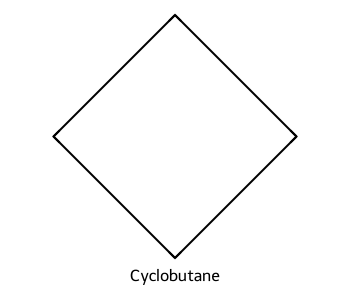

Saved: rdkit_visual_outputs/03_cyclobutane.png


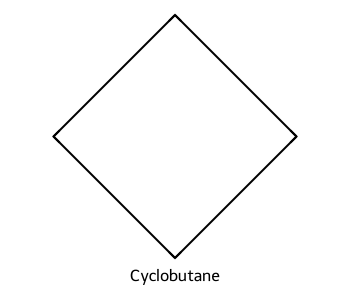

In [8]:
# ============================================================
# 3. MOL BLOCK EXPORT AND VISUALIZATION
# ============================================================

print_section("3. MOL block export")

mol_cyclobutane = Chem.MolFromSmiles("C1CCC1")
mol_cyclobutane.SetProp("_Name", "cyclobutane")

print("SMILES: C1CCC1")
print("MOL block:")
print(Chem.MolToMolBlock(mol_cyclobutane))

show_mol(mol_cyclobutane, title="Cyclobutane", filename="03_cyclobutane.png")


4. Compute 2D coordinates
SMILES: c1cc2ccncn2c1
2D coordinates were computed and stored in the molecule.


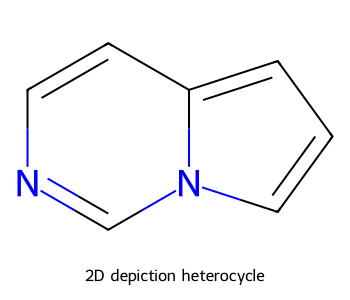

Saved: rdkit_visual_outputs/04_2d_heterocycle.png


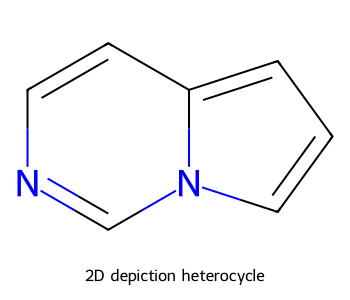

In [9]:
# ============================================================
# 4. 2D COORDINATES
# ============================================================

print_section("4. Compute 2D coordinates")

mol_2d = Chem.MolFromSmiles("c1nccc2n1ccc2")
AllChem.Compute2DCoords(mol_2d)

print("SMILES:", Chem.MolToSmiles(mol_2d))
print("2D coordinates were computed and stored in the molecule.")

show_mol(mol_2d, title="2D depiction heterocycle", filename="04_2d_heterocycle.png")


5. Aromaticity and Kekulization
Aromatic benzene SMILES: c1ccccc1
Kekule benzene SMILES: C1=CC=CC=C1


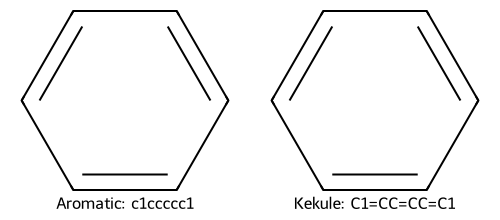

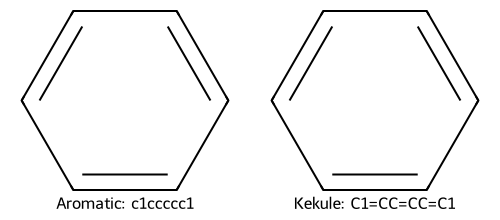

In [10]:
# ============================================================
# 5. AROMATICITY AND KEKULIZATION
# ============================================================

print_section("5. Aromaticity and Kekulization")

benzene_aromatic = Chem.MolFromSmiles("c1ccccc1")
benzene_kekule = Chem.Mol(benzene_aromatic)
Chem.Kekulize(benzene_kekule, clearAromaticFlags=True)

print("Aromatic benzene SMILES:", Chem.MolToSmiles(benzene_aromatic))
print("Kekule benzene SMILES:", Chem.MolToSmiles(benzene_kekule, kekuleSmiles=True))

show_grid(
    [benzene_aromatic, benzene_kekule],
    legends=["Aromatic: c1ccccc1", "Kekule: C1=CC=CC=C1"],
    title="05_aromatic_vs_kekule",
    mols_per_row=2,
)


6. Add and remove hydrogens
Ethanol atoms without explicit H: 3
Ethanol atoms with explicit H: 9
After removing H: 3


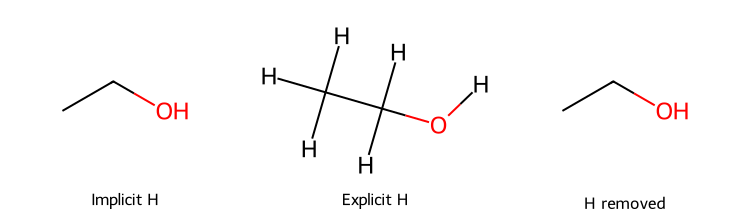

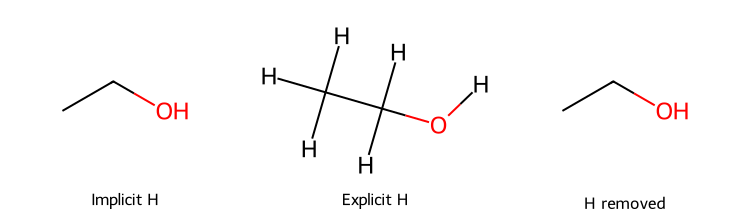

In [11]:
# ============================================================
# 6. ADD AND REMOVE HYDROGENS
# ============================================================

print_section("6. Add and remove hydrogens")

ethanol = Chem.MolFromSmiles("CCO")
ethanol_with_h = Chem.AddHs(ethanol)
ethanol_no_h = Chem.RemoveHs(ethanol_with_h)

print("Ethanol atoms without explicit H:", ethanol.GetNumAtoms())
print("Ethanol atoms with explicit H:", ethanol_with_h.GetNumAtoms())
print("After removing H:", ethanol_no_h.GetNumAtoms())

show_grid(
    [ethanol, ethanol_with_h, ethanol_no_h],
    legends=["Implicit H", "Explicit H", "H removed"],
    title="06_add_remove_hydrogens",
    mols_per_row=3,
)


7. Generate 3D conformer and optimize
Embed status: 0
MMFF optimization status: 0
MOL block with 3D coordinates:

     RDKit          3D

 16 16  0  0  0  0  0  0  0  0999 V2000
    1.2235   -0.8110    0.7490 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.7830    0.0914   -0.3652 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.6252    1.0638   -0.0757 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.1496   -0.1308    0.5323 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.0504   -0.8342   -0.3532 O   0  0  0  0  0  0  0  0  0  0  0  0
   -2.3204   -0.2301   -0.5516 C   0  0  0  0  0  0  0  0  0  0  0  0
    1.6566   -0.6213    1.7378 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.2654   -1.8841    0.5437 H   0  0  0  0  0  0  0  0  0  0  0  0
    1.7376   -0.3616   -1.3622 H   0  0  0  0  0  0  0  0  0  0  0  0
    2.7883    0.4858   -0.1981 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.1837    1.5314   -0.9595 H   0  0  0  0  0  0  0  0  0  0  0  0
    0.8687    1.8446    0.6538 H   0  0  0  0  0  0

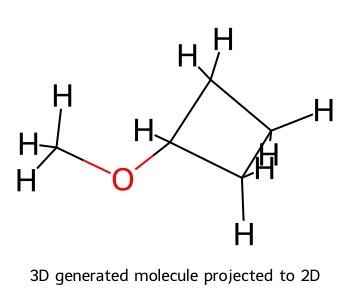

Saved: rdkit_visual_outputs/07_3d_projected.png


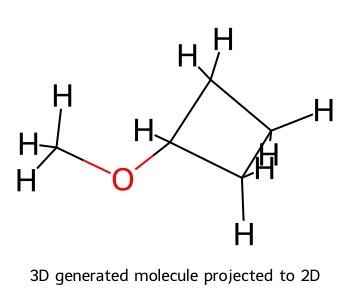

In [12]:
# ============================================================
# 7. GENERATE 3D CONFORMER + OPTIMIZE
# ============================================================

print_section("7. Generate 3D conformer and optimize")

mol_3d = Chem.MolFromSmiles("C1CCC1OC")
mol_3d_h = Chem.AddHs(mol_3d)

params = AllChem.ETKDGv3()
params.randomSeed = 0xF00D
embed_status = AllChem.EmbedMolecule(mol_3d_h, params)
mmff_status = AllChem.MMFFOptimizeMolecule(mol_3d_h)

print("Embed status:", embed_status)
print("MMFF optimization status:", mmff_status)
print("MOL block with 3D coordinates:")
print(Chem.MolToMolBlock(mol_3d_h)[:1000], "...\n")

show_mol(mol_3d_h, title="3D generated molecule projected to 2D", filename="07_3d_projected.png")


8. Multiple conformers
Number of conformers: 10
RMSD list relative to first conformer: [0.9344612256024382, 1.0829668692059997, 1.366934307442396, 1.199137647956119, 0.9868648117955736, 1.0210029389227764, 1.426953514569094, 1.2315396546189363, 1.2676884586735393]


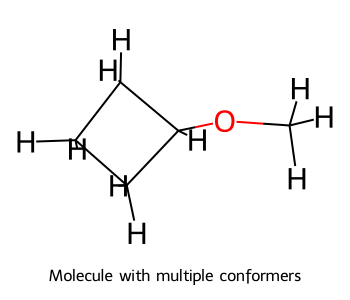

Saved: rdkit_visual_outputs/08_multiple_conformers.png


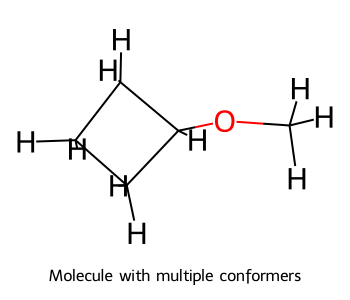

In [13]:
# ============================================================
# 8. MULTIPLE CONFORMERS
# ============================================================

print_section("8. Multiple conformers")

mol_conf = Chem.AddHs(Chem.MolFromSmiles("C1CCC1OC"))
conf_ids = AllChem.EmbedMultipleConfs(mol_conf, numConfs=10, randomSeed=123)

rmslist = []
AllChem.AlignMolConformers(mol_conf, RMSlist=rmslist)

print("Number of conformers:", len(conf_ids))
print("RMSD list relative to first conformer:", rmslist)

show_mol(mol_conf, title="Molecule with multiple conformers", filename="08_multiple_conformers.png")


9. Inspect atoms, bonds, and neighbors


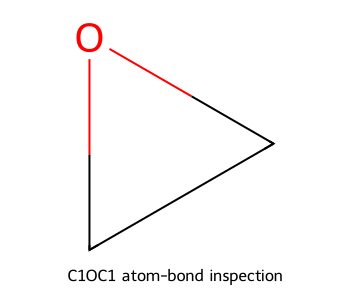

Saved: rdkit_visual_outputs/09_c1oc1.png
Atoms:
idx= 0 symbol= C atomic_num= 6 explicit_valence= 2
idx= 1 symbol= O atomic_num= 8 explicit_valence= 2
idx= 2 symbol= C atomic_num= 6 explicit_valence= 2

Bonds:
bond_idx= 0 begin= 0 end= 1 type= SINGLE
bond_idx= 1 begin= 1 end= 2 type= SINGLE
bond_idx= 2 begin= 2 end= 0 type= SINGLE

Neighbors of atom 0: ['O', 'C']


[15:50:50] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:50:50] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead
[15:50:50] DEPRECATION WARNING: please use GetValence(Chem.ValenceType.EXPLICIT) instead


In [14]:
# ============================================================
# 9. ATOMS, BONDS, NEIGHBORS
# ============================================================

print_section("9. Inspect atoms, bonds, and neighbors")

ring_mol = Chem.MolFromSmiles("C1OC1")
show_mol(ring_mol, title="C1OC1 atom-bond inspection", filename="09_c1oc1.png")

print("Atoms:")
for atom in ring_mol.GetAtoms():
    print(
        "idx=", atom.GetIdx(),
        "symbol=", atom.GetSymbol(),
        "atomic_num=", atom.GetAtomicNum(),
        "explicit_valence=", atom.GetExplicitValence(),
    )

print("\nBonds:")
for bond in ring_mol.GetBonds():
    print(
        "bond_idx=", bond.GetIdx(),
        "begin=", bond.GetBeginAtomIdx(),
        "end=", bond.GetEndAtomIdx(),
        "type=", bond.GetBondType(),
    )

atom0 = ring_mol.GetAtomWithIdx(0)
print("\nNeighbors of atom 0:", [x.GetSymbol() for x in atom0.GetNeighbors()])


10. Ring information


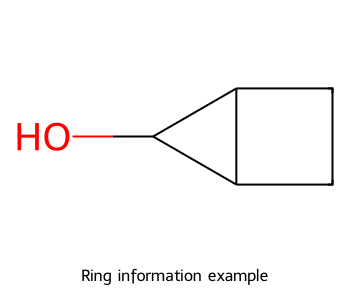

Saved: rdkit_visual_outputs/10_ring_info.png
Atom 0 in ring? False
Atom 1 in ring? True
Atom 2 in ring size 3? True
Atom 2 in ring size 4? True
Number of rings: 2
Ring 0 atom indices: [1, 2, 3]
Ring 1 atom indices: [4, 5, 2, 3]


In [15]:
# ============================================================
# 10. RING INFORMATION
# ============================================================

print_section("10. Ring information")

ring_example = Chem.MolFromSmiles("OC1C2C1CC2")
show_mol(ring_example, title="Ring information example", filename="10_ring_info.png")

print("Atom 0 in ring?", ring_example.GetAtomWithIdx(0).IsInRing())
print("Atom 1 in ring?", ring_example.GetAtomWithIdx(1).IsInRing())
print("Atom 2 in ring size 3?", ring_example.GetAtomWithIdx(2).IsInRingSize(3))
print("Atom 2 in ring size 4?", ring_example.GetAtomWithIdx(2).IsInRingSize(4))

ssr = Chem.GetSymmSSSR(ring_example)
print("Number of rings:", len(ssr))
for i, ring in enumerate(ssr):
    print(f"Ring {i} atom indices:", list(ring))



11. Grid visualization of multiple molecules


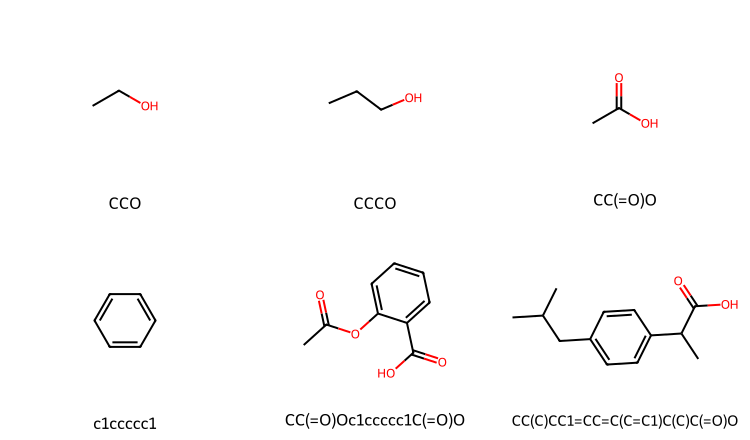

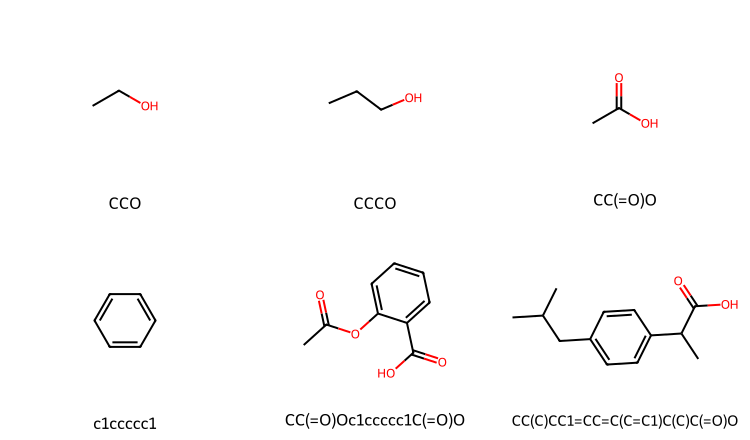

In [16]:
# ============================================================
# 11. MOLECULE GRID
# ============================================================

print_section("11. Grid visualization of multiple molecules")

smiles_examples = [
    "CCO",                       # ethanol
    "CCCO",                      # propanol
    "CC(=O)O",                   # acetic acid
    "c1ccccc1",                  # benzene
    "CC(=O)Oc1ccccc1C(=O)O",     # aspirin
    "CC(C)CC1=CC=C(C=C1)C(C)C(=O)O",  # ibuprofen-like
]

# Convert SMILES into RDKit molecules
mol_examples = [Chem.MolFromSmiles(s) for s in smiles_examples]

# Display molecules in grid
show_grid(
    mol_examples,
    legends=smiles_examples,
    title="11_molecule_grid",
    mols_per_row=3,
)


12. Substructure search and highlighting
Substructure pattern SMARTS: ccO
Matches: ((0, 5, 6), (4, 5, 6))


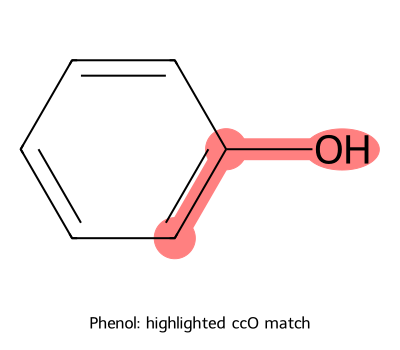

Saved: rdkit_visual_outputs/12_substructure_highlight.png


In [17]:
# ============================================================
# 12. SUBSTRUCTURE SEARCH + HIGHLIGHT
# ============================================================

print_section("12. Substructure search and highlighting")

phenol = Chem.MolFromSmiles("c1ccccc1O")
pattern = Chem.MolFromSmarts("ccO")

matches = phenol.GetSubstructMatches(pattern)
print("Substructure pattern SMARTS: ccO")
print("Matches:", matches)

# Highlight first match if found.
if matches:
    hit_atoms = list(matches[0])
    hit_bonds = []
    for bond in pattern.GetBonds():
        a1 = hit_atoms[bond.GetBeginAtomIdx()]
        a2 = hit_atoms[bond.GetEndAtomIdx()]
        hit_bonds.append(phenol.GetBondBetweenAtoms(a1, a2).GetIdx())

    img = Draw.MolToImage(
        phenol,
        size=(400, 350),
        highlightAtoms=hit_atoms,
        highlightBonds=hit_bonds,
        legend="Phenol: highlighted ccO match",
    )
    if display is not None:
        display(img)
    img.save(OUTDIR / "12_substructure_highlight.png")
    print("Saved:", OUTDIR / "12_substructure_highlight.png")


13. Delete substructure
Original SMILES: CC(=O)O
After deleting carboxyl pattern: C


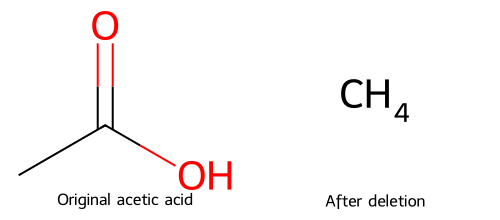

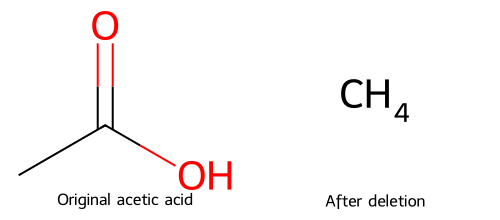

In [18]:
# ============================================================
# 13. DELETE SUBSTRUCTURE
# ============================================================

print_section("13. Delete substructure")

acetic_acid = Chem.MolFromSmiles("CC(=O)O")
carboxyl_pattern = Chem.MolFromSmarts("C(=O)[OH]")
removed = AllChem.DeleteSubstructs(acetic_acid, carboxyl_pattern)

print("Original SMILES:", Chem.MolToSmiles(acetic_acid))
print("After deleting carboxyl pattern:", Chem.MolToSmiles(removed))

show_grid(
    [acetic_acid, removed],
    legends=["Original acetic acid", "After deletion"],
    title="13_delete_substructure",
    mols_per_row=2,
)


14. Replace substructure
Original amide: CC(N)=O
After replacement: COC(C)=O


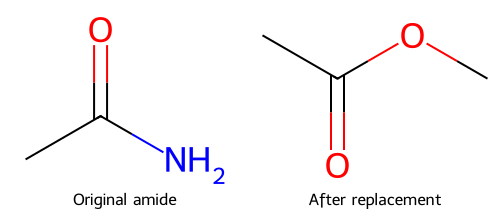

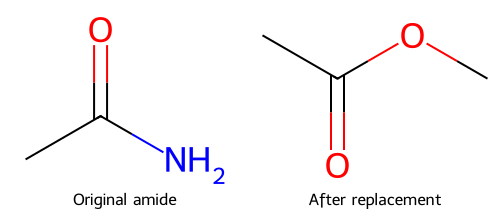

In [19]:

# ============================================================
# 14. REPLACE SUBSTRUCTURE
# ============================================================

print_section("14. Replace substructure")

amide = Chem.MolFromSmiles("CC(=O)N")
replace_pattern = Chem.MolFromSmarts("[$(NC(=O))]")
replacement = Chem.MolFromSmiles("OC")
replaced_tuple = AllChem.ReplaceSubstructs(amide, replace_pattern, replacement)
replaced = replaced_tuple[0] if replaced_tuple else None

print("Original amide:", Chem.MolToSmiles(amide))
if replaced is not None:
    print("After replacement:", Chem.MolToSmiles(replaced))

show_grid(
    [amide, replaced],
    legends=["Original amide", "After replacement"],
    title="14_replace_substructure",
    mols_per_row=2,
)


15. Fingerprints, Tanimoto similarity, Dice similarity


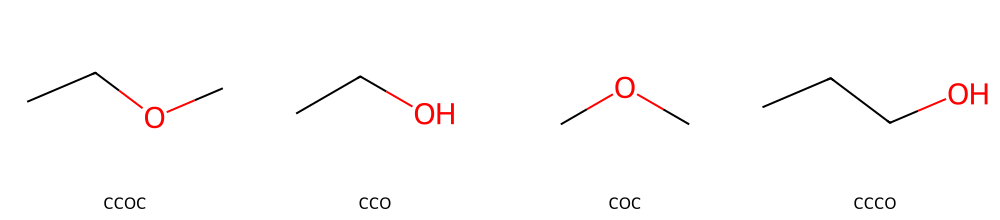

Pairwise similarity to first molecule: CCOC
CCOC vs CCO | Tanimoto=0.600 | Dice=0.750
CCOC vs COC | Tanimoto=0.400 | Dice=0.571
CCOC vs CCCO | Tanimoto=0.429 | Dice=0.600


In [20]:
# ============================================================
# 15. FINGERPRINTS + TANIMOTO + DICE SIMILARITY
# ============================================================

print_section("15. Fingerprints, Tanimoto similarity, Dice similarity")

sim_smiles = [
    "CCOC",  # ethoxyethane-like
    "CCO",   # ethanol
    "COC",   # dimethyl ether
    "CCCO",  # propanol
]

sim_mols = [Chem.MolFromSmiles(s) for s in sim_smiles]
fpgen = AllChem.GetRDKitFPGenerator()
fps = [fpgen.GetFingerprint(m) for m in sim_mols]

show_grid(
    sim_mols,
    legends=sim_smiles,
    title="15_similarity_molecules",
    mols_per_row=4,
)

print("Pairwise similarity to first molecule:", sim_smiles[0])
for i in range(1, len(sim_mols)):
    tanimoto = DataStructs.TanimotoSimilarity(fps[0], fps[i])
    dice = DataStructs.DiceSimilarity(fps[0], fps[i])
    print(
        f"{sim_smiles[0]} vs {sim_smiles[i]} | "
        f"Tanimoto={tanimoto:.3f} | Dice={dice:.3f}"
    )



16. Explicit Dice similarity example
Molecule 1: CCO
Molecule 2: CCCO
Tanimoto similarity: 0.6
Dice similarity: 0.75


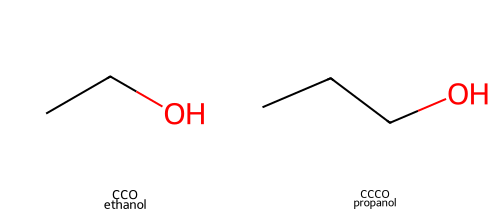

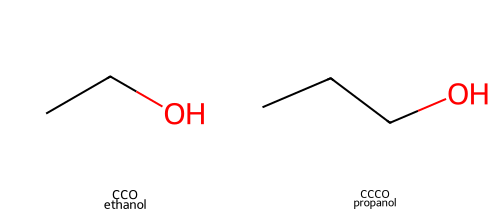

In [21]:
# ============================================================
# 16. EXPLICIT DICE SIMILARITY EXAMPLE
# ============================================================

print_section("16. Explicit Dice similarity example")

smiles1 = "CCO"   # ethanol
smiles2 = "CCCO"  # propanol

mol1 = Chem.MolFromSmiles(smiles1)
mol2 = Chem.MolFromSmiles(smiles2)

fp1 = AllChem.RDKFingerprint(mol1)
fp2 = AllChem.RDKFingerprint(mol2)

dice_score = DataStructs.DiceSimilarity(fp1, fp2)
tanimoto_score = DataStructs.TanimotoSimilarity(fp1, fp2)

print("Molecule 1:", smiles1)
print("Molecule 2:", smiles2)
print("Tanimoto similarity:", tanimoto_score)
print("Dice similarity:", dice_score)

show_grid(
    [mol1, mol2],
    legends=[f"{smiles1}\nethanol", f"{smiles2}\npropanol"],
    title="16_dice_similarity_ethanol_propanol",
    mols_per_row=2,
)

In [22]:
print(fp1)
print(fp2)


17. SELFIES encoding and decoding
Original SMILES: CCO
SELFIES: [C][C][O]
Decoded SMILES: CCO


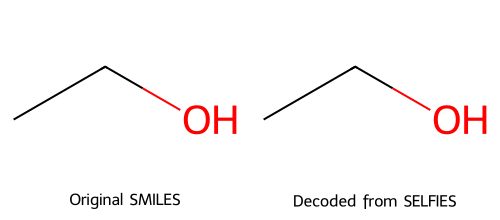

In [23]:
# ============================================================
# 17. SELFIES ENCODING AND DECODING
# ============================================================

print_section("17. SELFIES encoding and decoding")

if sf is None:
    print("SELFIES is not installed. Install with: pip install selfies")
else:
    smiles_selfies = "CCO"
    selfie = sf.encoder(smiles_selfies)
    decoded = sf.decoder(selfie)

    print("Original SMILES:", smiles_selfies)
    print("SELFIES:", selfie)
    print("Decoded SMILES:", decoded)

    mol_original = Chem.MolFromSmiles(smiles_selfies)
    mol_decoded = Chem.MolFromSmiles(decoded)

    show_grid(
        [mol_original, mol_decoded],
        legends=["Original SMILES", "Decoded from SELFIES"],
        title="17_selfies_ethanol_roundtrip",
        mols_per_row=2,
    )



18. Aspirin SMILES, SELFIES, and visualization
Aspirin SMILES: CC(=O)Oc1ccccc1C(=O)O
Canonical SMILES: CC(=O)Oc1ccccc1C(=O)O


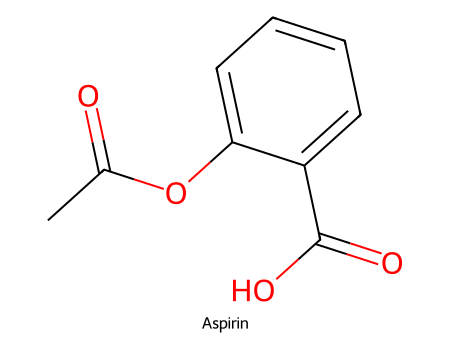

Saved: rdkit_visual_outputs/18_aspirin.png
Aspirin SELFIES:
[C][C][=Branch1][C][=O][O][C][=C][C][=C][C][=C][Ring1][=Branch1][C][=Branch1][C][=O][O]
Decoded SMILES: CC(=O)OC1=CC=CC=C1C(=O)O


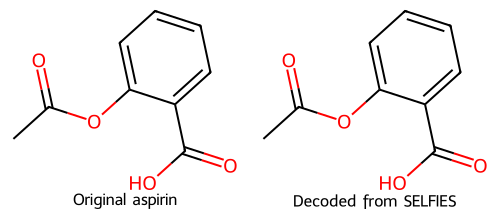

In [24]:
# ============================================================
# 18. ASPIRIN: SMILES -> IMAGE -> SELFIES -> DECODED IMAGE
# ============================================================

print_section("18. Aspirin SMILES, SELFIES, and visualization")

aspirin_smiles = "CC(=O)Oc1ccccc1C(=O)O"
aspirin = Chem.MolFromSmiles(aspirin_smiles)

print("Aspirin SMILES:", aspirin_smiles)
print("Canonical SMILES:", Chem.MolToSmiles(aspirin))

show_mol(aspirin, title="Aspirin", filename="18_aspirin.png", size=(450, 350))

if sf is not None:
    aspirin_selfie = sf.encoder(aspirin_smiles)
    aspirin_decoded_smiles = sf.decoder(aspirin_selfie)
    aspirin_decoded = Chem.MolFromSmiles(aspirin_decoded_smiles)

    print("Aspirin SELFIES:")
    print(aspirin_selfie)
    print("Decoded SMILES:", aspirin_decoded_smiles)

    show_grid(
        [aspirin, aspirin_decoded],
        legends=["Original aspirin", "Decoded from SELFIES"],
        title="18_aspirin_selfies_roundtrip",
        mols_per_row=2,
    )


19. Aspirin fragments: acetyl, benzene, carboxylic acid


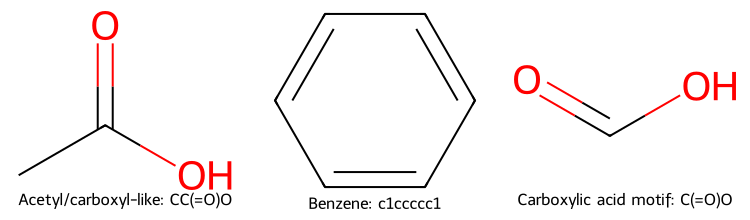

Fragment SMILES -> SELFIES
Acetyl/carboxyl-like: CC(=O)O
  SMILES : CC(=O)O
  SELFIES: [C][C][=Branch1][C][=O][O]
Benzene: c1ccccc1
  SMILES : c1ccccc1
  SELFIES: [C][=C][C][=C][C][=C][Ring1][=Branch1]
Carboxylic acid motif: C(=O)O
  SMILES : C(=O)O
  SELFIES: [C][=Branch1][C][=O][O]


In [25]:
# ============================================================
# 19. ASPIRIN FUNCTIONAL GROUP FRAGMENTS
# ============================================================

print_section("19. Aspirin fragments: acetyl, benzene, carboxylic acid")

fragment_smiles = [
    "CC(=O)O",       # acetate/acetic acid-like fragment
    "c1ccccc1",      # benzene
    "C(=O)O",        # formic acid/carboxyl fragment as standalone molecule
]

fragment_names = [
    "Acetyl/carboxyl-like: CC(=O)O",
    "Benzene: c1ccccc1",
    "Carboxylic acid motif: C(=O)O",
]

fragment_mols = [Chem.MolFromSmiles(s) for s in fragment_smiles]

show_grid(
    fragment_mols,
    legends=fragment_names,
    title="19_aspirin_fragments",
    mols_per_row=3,
)

if sf is not None:
    print("Fragment SMILES -> SELFIES")
    for name, smi in zip(fragment_names, fragment_smiles):
        print(name)
        print("  SMILES :", smi)
        print("  SELFIES:", sf.encoder(smi))



20. Highlight carboxylic acid group in aspirin
Carboxylic acid SMARTS: C(=O)[OH]
Matches in aspirin: ((10, 11, 12),)


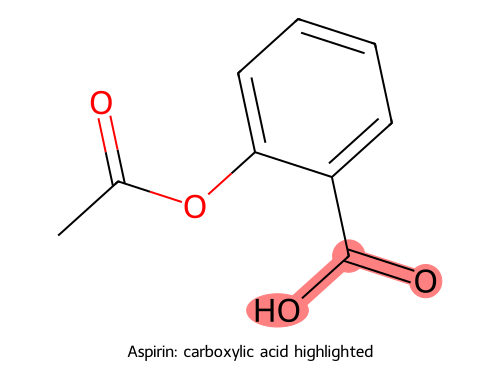

Saved: rdkit_visual_outputs/20_aspirin_carboxylic_acid_highlight.png


In [26]:
# ============================================================
# 20. CARBOXYLIC ACID MOTIF HIGHLIGHT IN ASPIRIN
# ============================================================

print_section("20. Highlight carboxylic acid group in aspirin")

carboxylic_acid_smarts = Chem.MolFromSmarts("C(=O)[OH]")
carboxyl_matches = aspirin.GetSubstructMatches(carboxylic_acid_smarts)
print("Carboxylic acid SMARTS: C(=O)[OH]")
print("Matches in aspirin:", carboxyl_matches)

if carboxyl_matches:
    hit_atoms = list(carboxyl_matches[0])
    hit_bonds = []
    for bond in carboxylic_acid_smarts.GetBonds():
        a1 = hit_atoms[bond.GetBeginAtomIdx()]
        a2 = hit_atoms[bond.GetEndAtomIdx()]
        hit_bonds.append(aspirin.GetBondBetweenAtoms(a1, a2).GetIdx())

    img = Draw.MolToImage(
        aspirin,
        size=(500, 380),
        highlightAtoms=hit_atoms,
        highlightBonds=hit_bonds,
        legend="Aspirin: carboxylic acid highlighted",
    )
    if display is not None:
        display(img)
    img.save(OUTDIR / "20_aspirin_carboxylic_acid_highlight.png")
    print("Saved:", OUTDIR / "20_aspirin_carboxylic_acid_highlight.png")

In [27]:
# ============================================================
# 21. WRITE OUTPUT FILES
# ============================================================

print_section("21. Write molecule files")

mol_file = OUTDIR / "aspirin.mol"
sdf_file = OUTDIR / "example_molecules.sdf"

with open(mol_file, "w") as f:
    f.write(Chem.MolToMolBlock(aspirin))

with Chem.SDWriter(str(sdf_file)) as writer:
    for m in mol_examples:
        if m is not None:
            writer.write(m)

print("Saved MOL file:", mol_file)
print("Saved SDF file:", sdf_file)



21. Write molecule files
Saved MOL file: rdkit_visual_outputs/aspirin.mol
Saved SDF file: rdkit_visual_outputs/example_molecules.sdf


In [28]:
# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print_section("22. Summary")

print("Core workflow:")
print("SMILES / SELFIES -> RDKit Mol -> molecular graph -> visualization / fingerprints / similarity / ML")
print("All images were saved in:", OUTDIR.resolve())



22. Summary
Core workflow:
SMILES / SELFIES -> RDKit Mol -> molecular graph -> visualization / fingerprints / similarity / ML
All images were saved in: /home/tanasa/CHEMISTRY_GNN/data/rdkit_visual_outputs
